In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from tensorflow.keras.models import load_model

In [2]:
# ----------------------------------------------------
# 1. 앙상블 모델 및 스케일러 로드
# ----------------------------------------------------
N_ENSEMBLE = 10
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]
MODEL_PATHS = [f'saved_models/pv_ensemble_model_{i+1}.keras' for i in range(N_ENSEMBLE)]
SCALER_DIR = '.' 

print("--- 모델 및 스케일러 로딩 ---")
ENSEMBLE_MODELS = [load_model(path, compile=False) for path in MODEL_PATHS]
X_SCALER_LOADED = joblib.load(os.path.join(SCALER_DIR, 'scaler_X_pvmodule.joblib'))

--- 모델 및 스케일러 로딩 ---


C:\Users\admin\anaconda3\envs\py31010_auto\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



--- [Deflection(mm)] SHAP Value 계산 시작 (시간이 다소 소요됩니다) ---


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\admin\AppData\Local\Temp\ipykernel_14392\3369940373.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


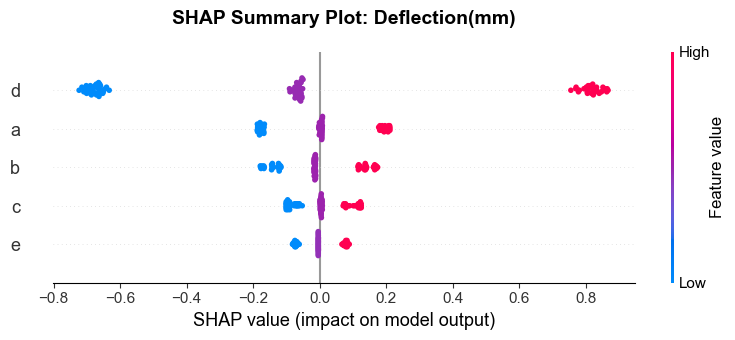


--- [Weight(kg)] SHAP Value 계산 시작 (시간이 다소 소요됩니다) ---


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\admin\AppData\Local\Temp\ipykernel_14392\3369940373.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


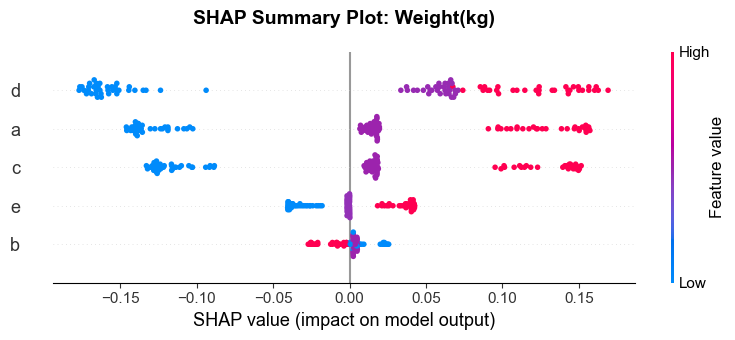


✅ SHAP 분석 및 시각화가 완료되었습니다.


In [6]:
# ----------------------------------------------------
# 2. SHAP 분석용 데이터 준비
# ----------------------------------------------------
DATA_PATH = '240205_pvmodule_rawdata.csv' # 실제 학습/테스트 데이터 파일명으로 변경하세요
df = pd.read_csv(DATA_PATH)

X_features = ['a', 'b', 'c', 'd', 'e']
X_data_raw = df[X_features].values

# 연산 속도를 위해 백그라운드 샘플 100개 무작위 추출
np.random.seed(42)
background_indices = np.random.choice(len(X_data_raw), size=100, replace=False)
X_background_scaled = X_SCALER_LOADED.transform(X_data_raw[background_indices])

# ----------------------------------------------------
# 3. 개별 타겟에 대한 Wrapper 함수 분리 (에러 해결 핵심)
# ----------------------------------------------------
def predict_deflection(X_scaled_array):
    preds = [model.predict(X_scaled_array, verbose=0) for model in ENSEMBLE_MODELS]
    mean_preds = np.mean(np.array(preds), axis=0)
    return mean_preds[:, 0] # 첫 번째 출력인 처짐량(Deflection)만 1D 배열로 반환

def predict_weight(X_scaled_array):
    preds = [model.predict(X_scaled_array, verbose=0) for model in ENSEMBLE_MODELS]
    mean_preds = np.mean(np.array(preds), axis=0)
    return mean_preds[:, 1] # 두 번째 출력인 무게(Weight)만 1D 배열로 반환

# ----------------------------------------------------
# 4. Kernel SHAP 실행 및 시각화 (각각 독립적으로 수행)
# ----------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
wrappers = [predict_deflection, predict_weight]

for i, target_name in enumerate(TARGET_NAMES):
    print(f"\n--- [{target_name}] SHAP Value 계산 시작 (시간이 다소 소요됩니다) ---")
    
    # 단일 출력 함수를 전달하여 형태 불일치 방지
    explainer = shap.KernelExplainer(wrappers[i], X_background_scaled)
    
    # 테스트 샘플(백그라운드와 동일)에 대한 SHAP 값 추출
    shap_values = explainer.shap_values(X_background_scaled)
    
    plt.figure(figsize=(8, 6))
    
    # 배열 형태가 정확히 일치하므로 에러 없이 Summary Plot 생성
    shap.summary_plot(
        shap_values, 
        X_background_scaled, 
        feature_names=X_features,
        show=False
    )
    
    plt.title(f"SHAP Summary Plot: {target_name}", pad=20, fontweight='bold', fontsize=14)
    plt.tight_layout()
    
    save_name = "SHAP_Summary_" + target_name.split('(')[0] + ".png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

print("\n✅ SHAP 분석 및 시각화가 완료되었습니다.")


--- [Deflection(mm)] SHAP Value 계산 시작 ---


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\admin\AppData\Local\Temp\ipykernel_14392\4162364766.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(



--- [Weight(kg)] SHAP Value 계산 시작 ---


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\admin\AppData\Local\Temp\ipykernel_14392\4162364766.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


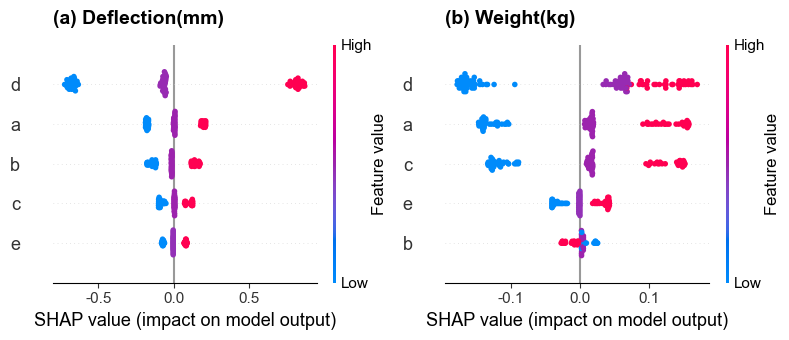


✅ 논문용 SHAP 통합 이미지(Fig4_SHAP_Summary_Combined.png)가 저장되었습니다.


In [7]:
# ----------------------------------------------------
# 4. Kernel SHAP 실행 및 시각화 (논문용 1x2 통합 출력)
# ----------------------------------------------------
import matplotlib.pyplot as plt
import shap

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

wrappers = [predict_deflection, predict_weight]

# A4 용지 폭에 맞춘 가로형 1x2 레이아웃 생성
# 가로 12, 세로 5 비율이 2단 편집 논문에 페이지 너비로 꽉 채워 넣기 가장 좋습니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

for i, target_name in enumerate(TARGET_NAMES):
    print(f"\n--- [{target_name}] SHAP Value 계산 시작 ---")
    
    explainer = shap.KernelExplainer(wrappers[i], X_background_scaled)
    shap_values = explainer.shap_values(X_background_scaled)
    
    # ★ 핵심: 현재 그래프를 그릴 축(ax)을 명시적으로 활성화
    plt.sca(axes[i])
    
    shap.summary_plot(
        shap_values, 
        X_background_scaled, 
        feature_names=X_features,
        show=False
    )
    
    # 논문용 서브 타이틀 추가 ((a) Deflection, (b) Weight)
    subplot_label = "(a)" if i == 0 else "(b)"
    
    # loc='left'를 통해 논문 스탠다드인 좌측 상단에 (a), (b) 배치
    axes[i].set_title(f"{subplot_label} {target_name}", fontsize=14, fontweight='bold', loc='left', pad=15)

# 축 간격 자동 조정 및 최종 저장
plt.tight_layout()
plt.savefig("Fig4_SHAP_Summary_Combined.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 논문용 SHAP 통합 이미지(Fig4_SHAP_Summary_Combined.png)가 저장되었습니다.")